In [28]:
import pandas as pd

df = pd.read_csv("student_placement_dataset.csv")

print(df.head())

    iq  cgpa  placed
0  107  5.84       0
1   97  5.52       1
2  109  8.18       1
3  122  8.53       1
4   96  5.16       0


In [29]:
X = df[['iq', 'cgpa']]
y = df['placed']

In [30]:
y

,placed
0,0
1,1
2,1
3,1
4,0
...,...
995,0
996,0
997,1
998,0


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")

Accuracy Score: 0.82
Confusion Matrix:
[[ 62  20]
 [ 16 102]]


In [35]:
y_prob = model.predict_proba(X_test)[:, 1]
y_prob

array([0.94817226, 0.98989126, 0.05897809, 0.8403784 , 0.14034025,
       0.32379282, 0.80287984, 0.06282764, 0.22038825, 0.59961703,
       0.97752758, 0.96990662, 0.78653827, 0.65044339, 0.88414307,
       0.51856064, 0.04397479, 0.72447366, 0.49593108, 0.87856345,
       0.17855136, 0.77845556, 0.98456904, 0.94414599, 0.80325141,
       0.8398878 , 0.19441904, 0.67870278, 0.73646894, 0.98820108,
       0.62671973, 0.03528339, 0.81808502, 0.05167097, 0.16239794,
       0.81540953, 0.60813773, 0.89810215, 0.96938045, 0.97834398,
       0.14571346, 0.13179919, 0.21938108, 0.07187145, 0.80294192,
       0.96719777, 0.92484558, 0.12004464, 0.97582212, 0.66332318,
       0.05044462, 0.97255879, 0.48901729, 0.89824526, 0.04257038,
       0.12088798, 0.44049932, 0.90525948, 0.96786991, 0.52005897,
       0.10985577, 0.97762199, 0.98432733, 0.65650094, 0.76383731,
       0.48106514, 0.84868566, 0.389735  , 0.91974144, 0.22727915,
       0.92792391, 0.65177719, 0.03955576, 0.08633894, 0.49293

In [36]:
import numpy as np

def predict_with_threshold(probs, threshold):
    return (probs >= threshold).astype(int)

thresholds = [0.1, 0.1, 0.3, 0.4, 0.5, 0.7, 0.8, 0.9]

for t in thresholds:
    preds = predict_with_threshold(y_prob, t)
    acc = np.mean(preds == y_test)
    print(f"Threshold: {t}, Accuracy: {acc}")

Threshold: 0.1, Accuracy: 0.71
Threshold: 0.1, Accuracy: 0.71
Threshold: 0.3, Accuracy: 0.83
Threshold: 0.4, Accuracy: 0.825
Threshold: 0.5, Accuracy: 0.82
Threshold: 0.7, Accuracy: 0.85
Threshold: 0.8, Accuracy: 0.79
Threshold: 0.9, Accuracy: 0.685


In [37]:
from sklearn.metrics import confusion_matrix

preds = predict_with_threshold(y_prob, 0.5)
cm = confusion_matrix(y_test, preds)

print(cm)

[[ 62  20]
 [ 16 102]]


In [38]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

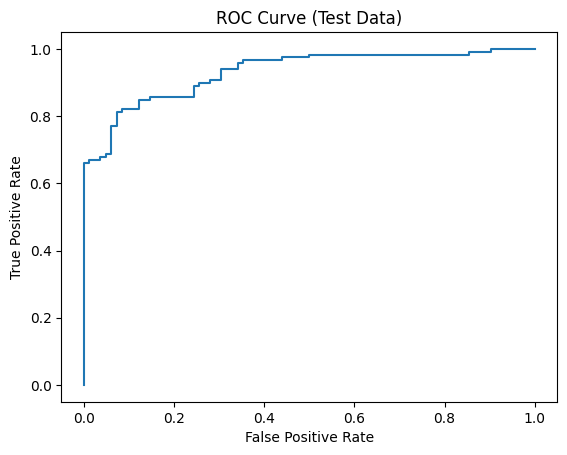

In [39]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Data)")
plt.show()

In [40]:
# Calculate Youden's J statistic for each threshold
j_scores = tpr - fpr

# Find the optimal threshold
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (maximizing J-statistic): {optimal_threshold:.2f}")

Optimal Threshold (maximizing J-statistic): 0.68


In [41]:
threshold = 0.68
y_pred_custom = (y_prob >= threshold).astype(int)

In [42]:
import numpy as np

accuracy = np.mean(y_pred_custom == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.86


In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_custom)
print(cm)

[[76  6]
 [22 96]]


The accuracy increased by 0.4%, from 82% to 86% after optimal threshold